# Графи и оптимизация

Отвори в Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/febse/opt2026/blob/main/06-Shortest-Path-LP.ipynb)


In [1]:
%pip install --quiet gurobipy

/home/boyko/opt2026/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# Създаваме нов ориентиран граф
G = nx.DiGraph()

# Добавяме възли с координати
positions = {
    'A': (0, 0),
    'B': (1, 2),
    'C': (2, 1),
    'D': (3, 3),
    'E': (4, 1),
    'F': (5, 2),
    'T': (6, 0),
    'H': (2, -1),
    'I': (4, -1),
    'J': (5, 3)
}

# Добавяме дъги с тегла
edges = [
    ('A', 'B', 12, 2, 0.001),
    ('A', 'C', 34, 3, 0.002),
    ('B', 'D', 7, 4, 0.003),
    ('C', 'D', 16, 1, 0.001),
    ('C', 'E', 20, 5, 0.001),
    ('D', 'F', 18, 2, 0.005),
    ('E', 'F', 10, 3, 0.002),
    ('F', 'T', 11, 1, 0.010),
    ('A', 'H', 23, 4, 0.008),
    ('H', 'C', 13, 2, 0.006),
    ('H', 'I', 7, 3, 0.002),
    ('I', 'E', 15, 2, 0.001),
    ('I', 'T', 25, 4, 0.002),
    ('D', 'J', 24, 3, 0.002),
    ('J', 'F', 18, 2, 0.008)
]

# Добавяме дъгите в графа
for u, v, c, w, prob in edges:
    G.add_edge(u, v, Capacity=c, Distance=w, Probability=prob)


In [3]:
def visualize_graph(G, positions, edge_attribute: str, title: str):

    if edge_attribute not in G.edges[next(iter(G.edges))]:
        raise ValueError(f"Графът няма атрибут '{edge_attribute}' за дъгите. Моля, изберете валиден атрибут от {list(G.edges[next(iter(G.edges))].keys())}.")
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos=positions, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)

    # Етикетите на дъгите
    edge_labels = nx.get_edge_attributes(G, edge_attribute)
    nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, rotate=False)

    for node, (x, y) in positions.items():
        circle = mpatches.Circle((x, y), radius=0.2, color='lightblue', alpha=0.5)
        plt.gca().add_patch(circle)

    plt.xlim(-1, 7)
    plt.ylim(-2, 5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.grid()
    plt.show()



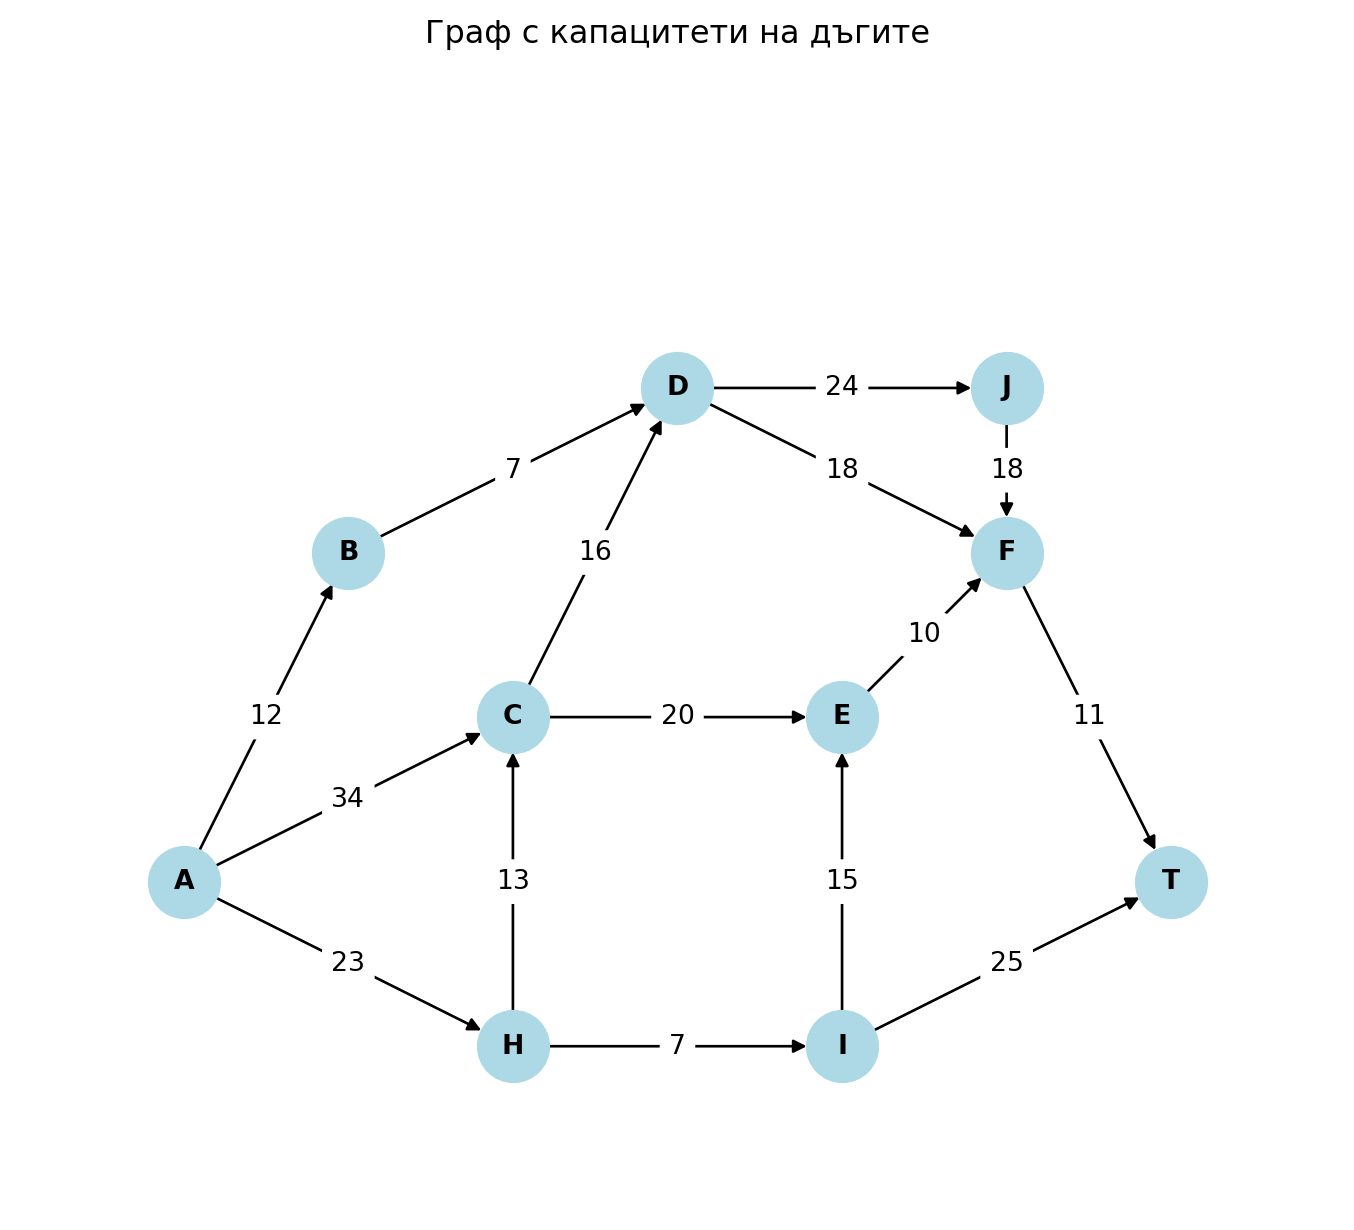

In [4]:
#| label: fig-graph-max-flow
#| fig-cap: "Водопреносна мрежа с капацитети на дъгите с начало в A и край в G. Стойностите на дъгите показват преносния им капацитет."

visualize_graph(G, positions, "Capacity", title='Граф с капацитети на дъгите')

## Най-голям поток (Maximum Flow)

Първо ще разгледаме класически проблем за намиране на най-големия поток в мрежа. Може да си представим, че @fig-graph-max-flow показва мрежа от водопроводни тръби, където всяка дъга има определен капацитет (стойностите на дъгите), който показва максималното количество вода, което може да премине през нея. Целта е да се определи колко вода може да се пренесе от началния възел A (източник, source) до крайния възел T (приемник, sink, target), като се спазват капацитетите на дъгите.

- Формулирайте проблема като задача за линейна оптимизация (LP)
- Решете задачата в [Excel](./excel/Max-Flow-Capacities.xlsx).


In [5]:
import gurobipy as gp
from gurobipy import GRB

mf = gp.Model("MaxFlow")

# Създаваме променливи за поток на всяка дъга
flow = mf.addVars(G.edges(), lb=0, name="Flow")

# Ограничения за капацитетите на дъгите
for u, v in G.edges():
    mf.addConstr(flow[u, v] <= G.edges[u, v]['Capacity'], name=f"Cap_{u}_{v}")

# Ограничения за запазване на потока (flow conservation)
for node in G.nodes():
    inflow = gp.quicksum(flow[u, node] for u in G.predecessors(node))
    outflow = gp.quicksum(flow[node, v] for v in G.successors(node))
    
    # Само за вътрешни възли, потокът влизащ = потокът излизащ
    if node != 'A' and node != 'T':
        mf.addConstr(inflow == outflow, name=f"FlowConservation_{node}")

# Целева функция: максимизиране на потока от A до T
mf.setObjective(gp.quicksum(flow[v, "T"] for v in G.predecessors("T")), GRB.MAXIMIZE)

mf.optimize()

if mf.status == GRB.OPTIMAL:
    print(f"Максимален поток от A до T: {mf.objVal}")
    for u, v in G.edges():
        if flow[u, v].x > 0.01:  # Показваме само значими потоци
            print(f"Поток по дъгата {u} -> {v}: {flow[u, v].x}")
else:
    print("Не е намерено оптимално решение.")

Restricted license - for non-production use only - expires 2027-11-29


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]


Thread count: 7 physical cores, 14 logical processors, using up to 14 threads


Optimize a model with 23 rows, 15 columns and 40 nonzeros (Max)


...

Iteration    Objective       Primal Inf.    Dual Inf.      Time


       0    1.8000000e+01   0.000000e+00   0.000000e+00      0s


Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.800000000e+01


Максимален поток от A до T: 18.0
Поток по дъгата A -> C: 11.0
Поток по дъгата A -> H: 7.0
Поток по дъгата C -> D: 11.0
Поток по дъгата D -> F: 11.0
Поток по дъгата F -> T: 11.0
Поток по дъгата H -> I: 7.0
Поток по дъгата I -> T: 7.0


In [6]:
mf.write("__max_flow_model.lp")

with open("__max_flow_model.lp", "r") as f:
    print(f.read())


\ Model MaxFlow
\ LP format - for model browsing. Use MPS format to capture full model detail.
Maximize
  Flow[F,T] + Flow[I,T]
Subject To
 Cap_A_B: Flow[A,B] <= 12
 Cap_A_C: Flow[A,C] <= 34
 Cap_A_H: Flow[A,H] <= 23
 Cap_B_D: Flow[B,D] <= 7
 Cap_C_D: Flow[C,D] <= 16
 Cap_C_E: Flow[C,E] <= 20
 Cap_D_F: Flow[D,F] <= 18
 Cap_D_J: Flow[D,J] <= 24
 Cap_E_F: Flow[E,F] <= 10
 Cap_F_T: Flow[F,T] <= 11
 Cap_H_C: Flow[H,C] <= 13
 Cap_H_I: Flow[H,I] <= 7
 Cap_I_E: Flow[I,E] <= 15
 Cap_I_T: Flow[I,T] <= 25
 Cap_J_F: Flow[J,F] <= 18
 FlowConservation_B: Flow[A,B] - Flow[B,D] = 0
 FlowConservation_C: Flow[A,C] - Flow[C,D] - Flow[C,E] + Flow[H,C] = 0
 FlowConservation_D: Flow[B,D] + Flow[C,D] - Flow[D,F] - Flow[D,J] = 0
 FlowConservation_E: Flow[C,E] - Flow[E,F] + Flow[I,E] = 0
 FlowConservation_F: Flow[D,F] + Flow[E,F] - Flow[F,T] + Flow[J,F] = 0
 FlowConservation_H: Flow[A,H] - Flow[H,C] - Flow[H,I] = 0
 FlowConservation_I: Flow[H,I] - Flow[I,E] - Flow[I,T] = 0
 FlowConservation_J: Flow[D,J] - Flo

In [7]:
# Създаваме pandas DataFrame за дъгите и техните атрибути

import pandas as pd
# Създаваме DataFrame от списъка с дъги
dt = pd.DataFrame(edges, columns=['Source', 'Target', 'Capacity', 'Distance', 'Probability']).set_index(['Source', 'Target'])

# Преобразуваме в таблица: редове = Source, колони = Target, стойности = Distance
distance_table = dt['Distance'].unstack('Target')
distance_table.to_excel('./excel/Shortest-Path-Distances.xlsx')  # Запазваме таблицата с разстояния в Excel файл

capacity_table = dt['Capacity'].unstack('Target')
capacity_table.to_excel('./excel/Max-Flow-Capacities.xlsx')

# dt

In [8]:
# Вземаме всички уникални стойности от многоиндекс
def get_unique_values(df):
    # Вземаме уникалните стойности от многоиндекса
    unique_values = set()
    for index in df.index:
        unique_values.update(index)
    return unique_values

nodes = get_unique_values(dt)

nodes

{'A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'T'}

In [9]:
# Оптимизационен модел в gurobi за задачата за най-кратък път

import gurobipy as gp
from gurobipy import GRB

# Създаваме нов модел
m = gp.Model("ShortestPath")

# Създаваме променливи за всяка дъга
x = m.addVars(dt.index, vtype=GRB.BINARY, name="x")

# Задаваме целева функция за минимизиране на общото разстояние
m.setObjective(x.prod(dt['Distance'].to_dict()), GRB.MINIMIZE)

# Добавяме ограничения за запазване на потока

# За всеки възел входящият поток трябва да е равен на изходящия поток

for node in nodes:
    if node == 'A':  # Изходен възел
        m.addConstr(x.sum(node, '*') == 1, name=f"source_{node}")
    elif node == 'T':  # Краен възел
        m.addConstr(x.sum('*', node) == 1, name=f"sink_{node}")
    else:
        m.addConstr(x.sum(node, '*') == x.sum('*', node), name=f"flow_{node}")
        m.addConstr(x.sum(node, '*') <= 1, name=f"outflow_{node}")
        m.addConstr(x.sum('*', node) <= 1, name=f"infow_{node}")

# Добавяме ограничения, че потокът е двоичен

m.write("shortest_path.lp")

with open("shortest_path.lp", "r") as file:
    print(file.read())

m.optimize()

\ Model ShortestPath
\ LP format - for model browsing. Use MPS format to capture full model detail.
Minimize
  2 x[A,B] + 3 x[A,C] + 4 x[B,D] + x[C,D] + 5 x[C,E] + 2 x[D,F] + 3 x[E,F]
   + x[F,T] + 4 x[A,H] + 2 x[H,C] + 3 x[H,I] + 2 x[I,E] + 4 x[I,T]
   + 3 x[D,J] + 2 x[J,F]
Subject To
 flow_E: - x[C,E] + x[E,F] - x[I,E] = 0
 outflow_E: x[E,F] <= 1
 infow_E: x[C,E] + x[I,E] <= 1
 flow_C: - x[A,C] + x[C,D] + x[C,E] - x[H,C] = 0
 outflow_C: x[C,D] + x[C,E] <= 1
 infow_C: x[A,C] + x[H,C] <= 1
 flow_I: - x[H,I] + x[I,E] + x[I,T] = 0
 outflow_I: x[I,E] + x[I,T] <= 1
 infow_I: x[H,I] <= 1
 flow_D: - x[B,D] - x[C,D] + x[D,F] + x[D,J] = 0
 outflow_D: x[D,F] + x[D,J] <= 1
 infow_D: x[B,D] + x[C,D] <= 1
 flow_J: - x[D,J] + x[J,F] = 0
 outflow_J: x[J,F] <= 1
 infow_J: x[D,J] <= 1
 sink_T: x[F,T] + x[I,T] = 1
 flow_B: - x[A,B] + x[B,D] = 0
 outflow_B: x[B,D] <= 1
 infow_B: x[A,B] <= 1
 flow_F: - x[D,F] - x[E,F] + x[F,T] - x[J,F] = 0
 outflow_F: x[F,T] <= 1
 infow_F: x[D,F] + x[E,F] + x[J,F] <= 1
 

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]


Thread count: 7 physical cores, 14 logical processors, using up to 14 threads


Optimize a model with 26 rows, 15 columns and 55 nonzeros (Min)


Model fingerprint: 0x9e33c5e1


...

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)


Thread count was 1 (of 14 available processors)


Solution count 2: 7 12 


Optimal solution found (tolerance 1.00e-04)


Best objective 7.000000000000e+00, best bound 7.000000000000e+00, gap 0.0000%


In [10]:
# Отпечатваме резултатите
if m.status == GRB.OPTIMAL:
    print('Намерено е оптимално решение:')
    for v in m.getVars():
        if v.x > 0:
            print(f'{v.varName}: {v.x}')

    print(f'Стойност на целевата функция: {m.objVal}')
else:
    print('Не е намерено оптимално решение.')

Намерено е оптимално решение:
x[A,C]: 1.0
x[C,D]: 1.0
x[D,F]: 1.0
x[F,T]: 1.0
Стойност на целевата функция: 7.0


Сега водачът е намерил оптималния си маршрут. Но той се интересува и от безопасността на пътуването си. Затова е събрал и данни за честотата на автомобилните катастрофи по пътищата. Той оценява пътищата със следните стойности, които представят вероятността за катастрофа (колоната `Probability` в набора от данни `dt`). Сега нашият водач иска да намери най-безопасния маршрут, т.е. този, при който вероятността да няма катастрофа е най-висока. Ще формулираме линеен модел, който решава този проблем. Приемаме, че катастрофите по отделните пътища настъпват независимо една от друга.

- Каква е вероятността по избрания маршрут да не се случи катастрофа?
- Как изглежда оптималният маршрут?
- Колко често трябва да очаква катастрофа водачът, ако кара по този маршрут два пъти на ден в продължение на пет години?
- Колко дълъг е най-безопасният маршрут?

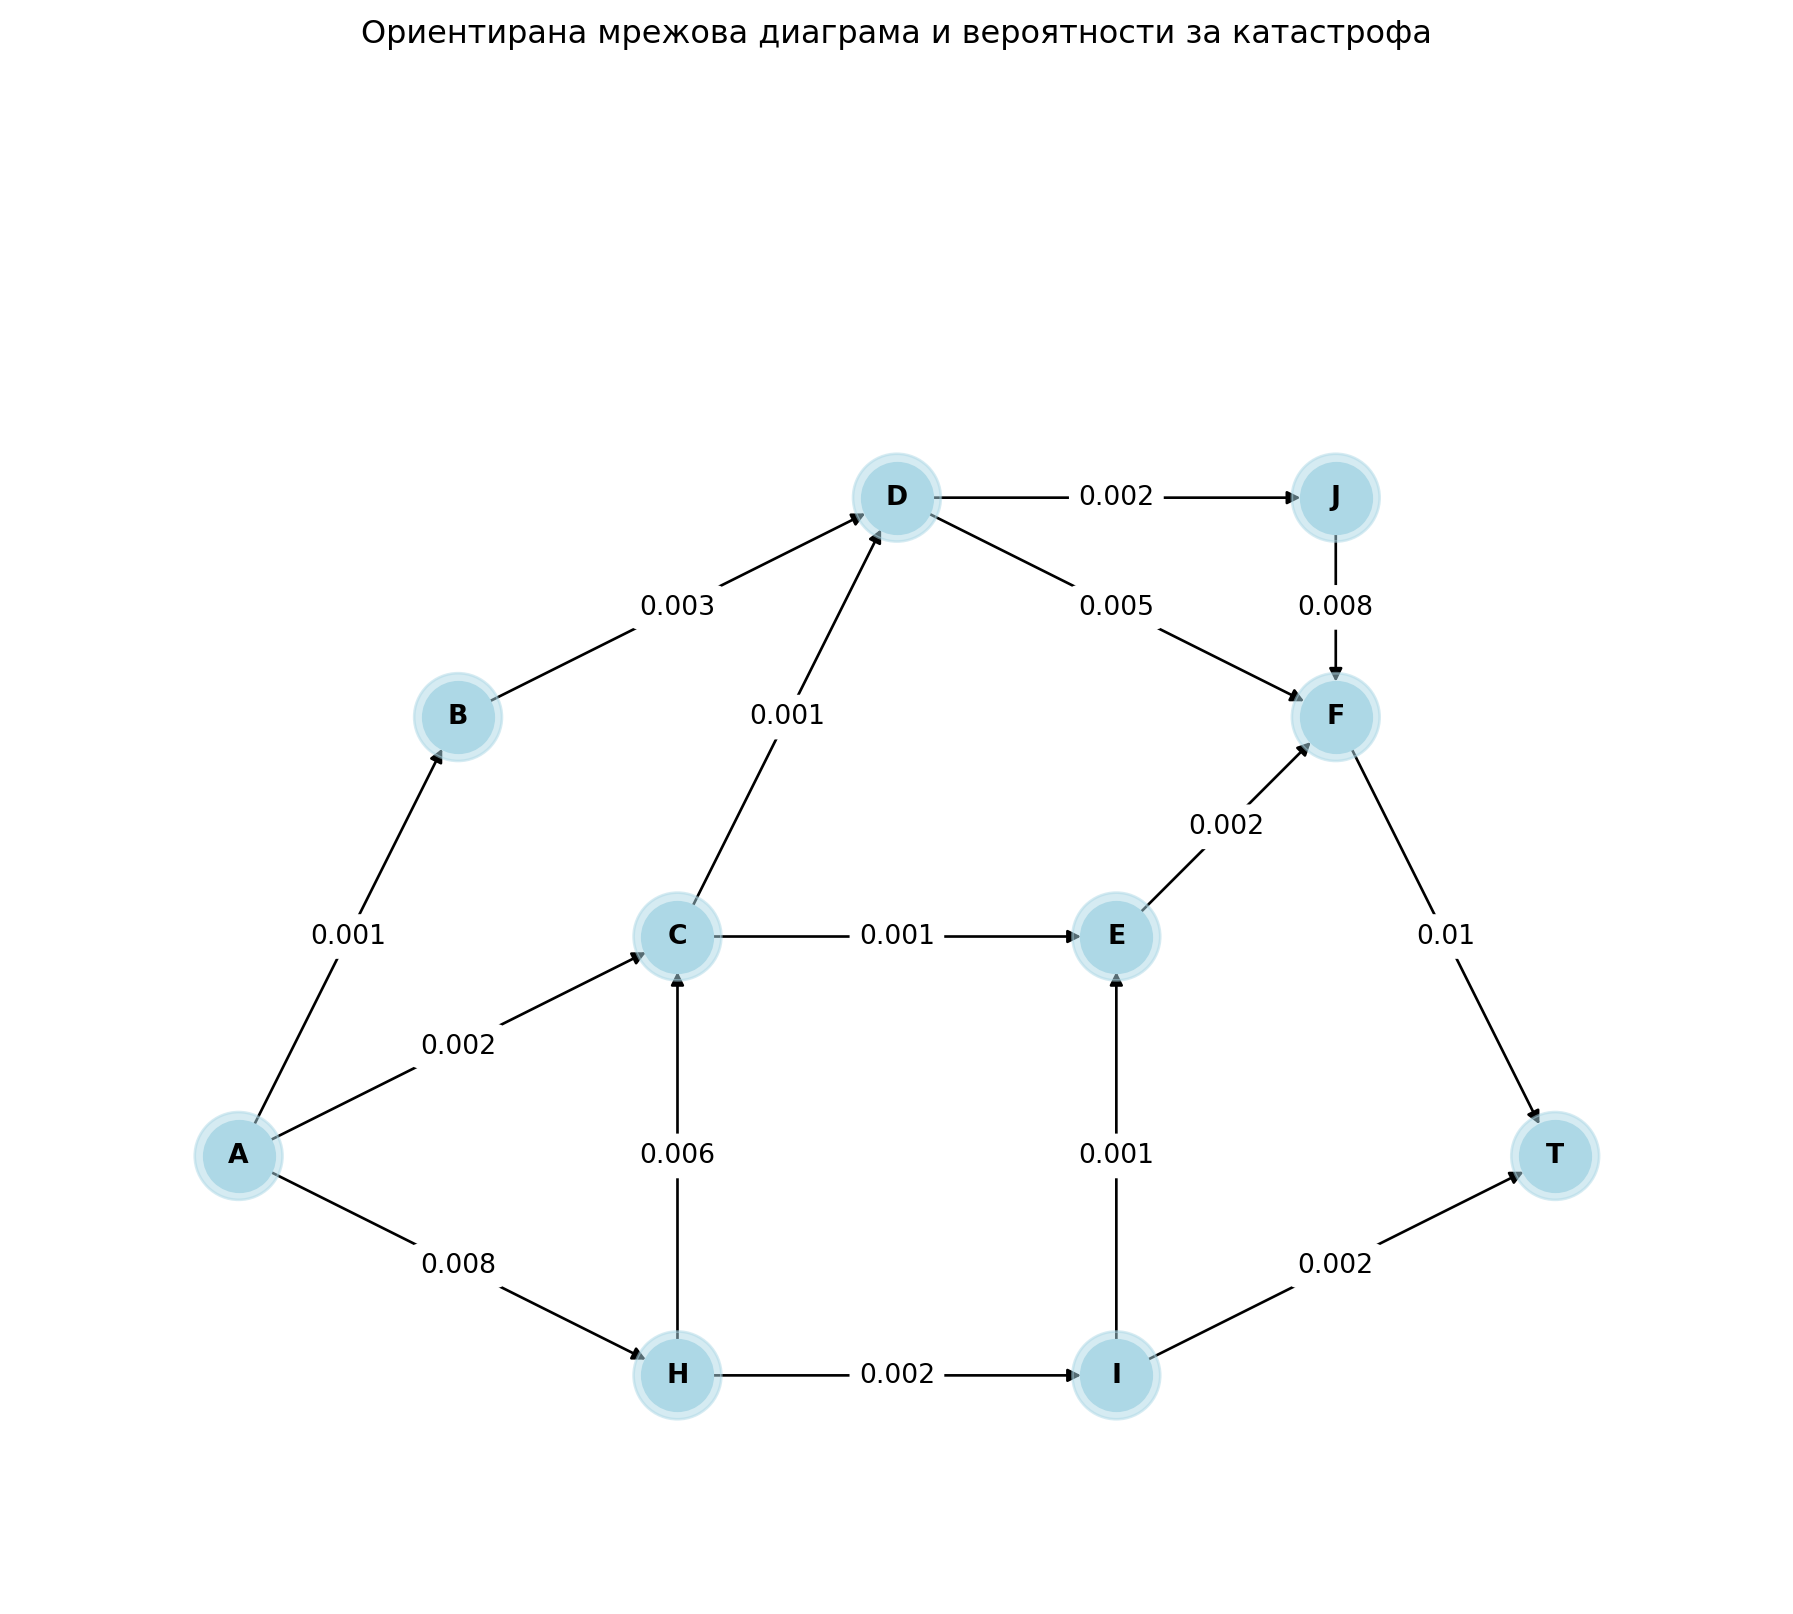

In [11]:
plt.figure(figsize=(10, 8))
nx.draw(G, pos=positions, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)
# Рисуваме етикетите на дъгите
edge_labels = nx.get_edge_attributes(G, 'Probability')

nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, rotate=False)

# Рисуваме кръгове около възлите
for node, (x, y) in positions.items():
    circle = mpatches.Circle((x, y), radius=0.2, color='lightblue', alpha=0.5)
    plt.gca().add_patch(circle)

# Задаваме граници и аспект
plt.xlim(-1, 7)
plt.ylim(-2, 5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Ориентирана мрежова диаграма и вероятности за катастрофа')
plt.grid()
plt.show()

Искаме да намерим най-безопасния маршрут. Това означава, че трябва да максимизираме вероятността да **няма** катастрофа. В набора от данни имаме вероятности за събитието "катастрофа" по отделните пътища.

Нека с $P(A_{s,e})$ означим вероятността за катастрофа по пътя с начало $s$ и край $e$. Катастрофите по различните отсечки са независими, затова вероятността да **няма** катастрофа е произведението от вероятностите да **няма** катастрофа на всяка отделна отсечка.

In [12]:
probs = np.array([0.008, 0.002, 0.002])
np.exp(np.log((1 - probs)).sum())

np.float64(0.988035968)

In [13]:
# Създаваме нов модел за най-безопасния маршрут
# Цел: максимизиране на вероятността за безопасност

import numpy as np

m1 = gp.Model("SafestPath")

# Създаваме променливи за всяка дъга
y = m1.addVars(dt.index, vtype=GRB.BINARY, name="y")

# За максимизиране на произведението на вероятности,
# работим с логаритми: max sum(log(1 - p_i)) * y_ij
prob_dict = {(u, v): dt.loc[(u, v), 'Probability'] for u, v in dt.index}
log_safety = {key: np.log(1 - prob) for key, prob in prob_dict.items()}

m1.setObjective(y.prod(log_safety), GRB.MAXIMIZE)

# Добавяме същите ограничения за потока
for node in nodes:
    if node == 'A':  # Изходен възел
        m1.addConstr(y.sum(node, '*') == 1, name=f"source_{node}")
    elif node == 'G':  # Краен възел
        m1.addConstr(y.sum('*', node) == 1, name=f"sink_{node}")
    else:
        m1.addConstr(y.sum(node, '*') == y.sum('*', node), name=f"flow_{node}")
        m1.addConstr(y.sum(node, '*') <= 1, name=f"outflow_{node}")
        m1.addConstr(y.sum('*', node) <= 1, name=f"inflow_{node}")

m1.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]


Thread count: 7 physical cores, 14 logical processors, using up to 14 threads


Optimize a model with 28 rows, 15 columns and 57 nonzeros (Max)


Model fingerprint: 0x7d983898


...

Thread count was 1 (of 14 available processors)


Solution count 0


No other solutions better than -1e+100


Model is infeasible


Best objective -, best bound -, gap -


In [14]:
# Отпечатваме резултатите

if m1.status == GRB.OPTIMAL:
    print('Намерен е оптимален безопасен маршрут:')
    print(f'Логаритъм на безопасностът: {m1.objVal}')
    print(f'Вероятност да няма катастрофа: {np.exp(m1.objVal):.4f}')
    print()
    total_distance = 0
    print('Маршрут:')
    for u, v in dt.index:
        if y[u, v].x > 0.5:
            distance = dt.loc[(u, v), 'Distance']
            prob = dt.loc[(u, v), 'Probability']
            total_distance += distance
            print(f'  {u} -> {v}: далжина = {distance}, вероятност за катастрофа = {prob}')
    print(f'\nОбща далжина: {total_distance}')
else:
    print('Не е намерен оптимално решение.')

Не е намерен оптимално решение.
